In [ ]:
##########################################
##### Examples - Differential ATAC-Seq in R #####
##########################################
#Created 10/12/2020
#Updated 9/15/2021
#Updated 9/9/2022
#Updated 9/5/2024
#Updated 9/2/2026


#Analyze Brain Open Chromatin Datasets from neurons in different brain regions
#Information for Genomics, Epigentics, and the Brain, lecture 5


The goal of this example is to characterize epigenetic (open chromatin) differences across regions and cell types of the human brain. To accomplish that goal, we will combine a statistical analysis in the R programming language with web tools to study the functional context of the differences.

We are given a dataset that is derived from various samples in the human brain (sampleInfo.brainAtac.1.csv). Samples come from a combination of cortical (M1 – Motor Cortex, dlPFC – dorsolateral prefrontal cortex) and striatal brain regions (NAc – nucleus accubmens, Put - Putamen). For each brain regions, a fluorescence-based technology was used to separate out neurons (NeuN+) from the glial cells (NeuN-). For each of the brain regions, ATAC-Seq was performed to measure open chromatin, which is an indicator of gene regulation. The regulatory regions that are marked by open chromatin are most often promoter regions directly upstream of the genes they regulate or in enhancer regions, which are primarily in intergenic regions or introns.

We called “peaks” from the resulting dataset, identify which segments of the genome were open chromatin in any of the samples (allMergePeak.simp.1.bed). The BED format gives that chromosome name, the start position, and the end/stop position of the region. For each peak, we counted the number of reads from each sample that overlap (allMergePeak.rawCounts.2.txt). This serves as a proxy for how open that region of chromatin is in the that sample.

The coordinates are in hg19.

In [1]:
##########################################
##### Install the relevant packages #####
##########################################
#This will take several minutes

if (!requireNamespace("BiocManager", quietly = TRUE)) #Install bioconductor, repository of bioinformatics packages in R
    install.packages("BiocManager")

BiocManager::install("edgeR"); #Install the EdgeR package

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.1 (2026-06-24)

Installing package(s) 'BiocVersion', 'edgeR'

also installing the dependencies ‘statmod’, ‘limma’, ‘locfit’


Old packages: 'bit64', 'curl', 'httr', 'nlme', 'rmarkdown', 'xtable'



In [2]:
install.packages("gplots");


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bitops’, ‘gtools’, ‘caTools’




In [3]:
install.packages("ggplot2");

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [4]:
##########################################
##### Load the libraries #####
##########################################
library(edgeR);
library(gplots);
library(ggplot2);
#library(googledrive);


Loading required package: limma


---------------------
gplots 3.3.0 loaded:
  * Use citation('gplots') for citation info.
  * Homepage: https://talgalili.github.io/gplots/
  * Report issues: https://github.com/talgalili/gplots/issues
  * Ask questions: https://stackoverflow.com/questions/tagged/gplots
  * Suppress this message with: suppressPackageStartupMessages(library(gplots))
---------------------



Attaching package: ‘gplots’


The following object is masked from ‘package:stats’:

    lowess




In [5]:
##########################################
##### Read in the relevant datasets #####
##########################################

##### Read in the information about each sample #####
atacSampInfoF <- read.csv(file="http://www.andrew.cmu.edu/user/apfennin/2020_Fall_GEB/HW4/sampleInfo.brainAtac.1.csv",stringsAsFactors=F);

#Create factors out of the relevant variables
atacSampInfoF$brainStructureT <- factor(c("cortex","cortex","striatum","striatum","cortex","cortex","striatum","striatum"),levels=c("striatum","cortex"));
atacSampInfoF$CellTypeT <- factor(atacSampInfoF$CellType,levels=c("NeuNNeg","NeuNPos"));
rownames(atacSampInfoF) <- atacSampInfoF$id;

atacSampInfoF; #Print the data.frame object


,id,BrainRegion,RegionAbv,CellType,brainStructureT,CellTypeT
,<chr>,<chr>,<chr>,<chr>,<fct>,<fct>
M1_NeuNPos,M1_NeuNPos,Primary motor cortex,M1,NeuNPos,cortex,NeuNPos
dlPFC_NeuNPos,dlPFC_NeuNPos,Dorsolateral prefrontal cortex,dlPFC,NeuNPos,cortex,NeuNPos
Put_NeuNPos,Put_NeuNPos,Putamen,Put,NeuNPos,striatum,NeuNPos
NAc_NeuNPos,NAc_NeuNPos,Nucleus accumbens,NAc,NeuNPos,striatum,NeuNPos
M1_NeuNNeg,M1_NeuNNeg,Primary motor cortex,M1,NeuNNeg,cortex,NeuNNeg
dlPFC_NeuNNeg,dlPFC_NeuNNeg,Dorsolateral prefrontal cortex,dlPFC,NeuNNeg,cortex,NeuNNeg
Put_NeuNNeg,Put_NeuNNeg,Putamen,Put,NeuNNeg,striatum,NeuNNeg
NAc_NeuNNeg,NAc_NeuNNeg,Nucleus accumbens,NAc,NeuNNeg,striatum,NeuNNeg


In [6]:
#Print out one row of the data frame
atacSampInfoF["M1_NeuNPos",]

#Print out one column of the data frame
atacSampInfoF[,"RegionAbv"]

,id,BrainRegion,RegionAbv,CellType,brainStructureT,CellTypeT
,<chr>,<chr>,<chr>,<chr>,<fct>,<fct>
M1_NeuNPos,M1_NeuNPos,Primary motor cortex,M1,NeuNPos,cortex,NeuNPos


[1] "M1"    "dlPFC" "Put"   "NAc"   "M1"    "dlPFC" "Put"   "NAc"

In [7]:
##### Read in the genomic coordinates on the peaks #####
atacRawBedF <- read.delim(file="http://www.andrew.cmu.edu/user/apfennin/2020_Fall_GEB/HW4/allMergePeak.simp.1.bed",header=F,stringsAsFactors=F);
colnames(atacRawBedF) <- c("chromosome","start","stop"); #The default columns of a bed file
rownames(atacRawBedF) <- paste(atacRawBedF$chromosome,":",atacRawBedF$start,"-",atacRawBedF$stop,sep="");
atacRawBedF[1:5,]; #Print the first five rows
dim(atacRawBedF); #Print the dimensions of the data frame

,chromosome,start,stop
,<chr>,<int>,<int>
chr1:191321-191487,chr1,191321,191487
chr1:631691-631928,chr1,631691,631928
chr1:632134-632318,chr1,632134,632318
chr1:634103-634930,chr1,634103,634930
chr1:778328-779024,chr1,778328,779024


[1] 118042      3

In [8]:
##### Read in the read counts per ATAC-Seq peak #####
atacRawCountM <- as.matrix(read.delim("http://www.andrew.cmu.edu/user/apfennin/2020_Fall_GEB/HW4/allMergePeak.rawCounts.2.txt"));
rownames(atacRawCountM) <- rownames(atacRawBedF);
atacRawCountM[1:5,]; #Print the first five rows
dim(atacRawCountM); #Print the dimensions of the matrix

,M1_NeuNPos,dlPFC_NeuNPos,Put_NeuNPos,NAc_NeuNPos,M1_NeuNNeg,dlPFC_NeuNNeg,Put_NeuNNeg,NAc_NeuNNeg
chr1:191321-191487,504,562,359,148,132,118,90,26
chr1:631691-631928,28,23,32,14,134,105,133,22
chr1:632134-632318,191,238,215,52,186,321,187,55
chr1:634103-634930,54,82,41,15,151,182,112,17
chr1:778328-779024,261,222,63,30,181,244,243,27


[1] 118042      8

In [9]:
##########################################
##### Clean the count matrix to focus on regions of interest #####
##########################################

####### Filter based on peak length ##############

#We are ultimately interested in identifying sequence features of interest in the cell type
#Sequences that are too long will have too many associated sequences
#Sequences that are too short may not contain enough information

sequenceLenV <- atacRawBedF$stop - atacRawBedF$start;

sequenceLenV[1:5]

keepSeqLenV <- rownames(atacRawBedF)[which(sequenceLenV >= 100 & sequenceLenV <= 500)];

length(sequenceLenV); #There are 118042 total sequences
length(keepSeqLenV); #31673 sequences meet the criteria

atacBedFilt1F <- atacRawBedF[keepSeqLenV,]; #Subset the data frame based on useable peaks
atacCountFilt1M <- atacRawCountM[keepSeqLenV,]; #Subset the matrix based on useable peaks

[1] 166 237 184 827 696

[1] 118042

[1] 31673

In [10]:
####### Filter based on number of reads ##############
#We want there to be enough reads to accurately quantify differences across samples
maxReadsV <- apply(atacCountFilt1M,1,max);
quantile(maxReadsV,0.1*(c(0:10)));

keepReadCountV <- rownames(atacBedFilt1F)[which(maxReadsV >= 167 & maxReadsV <= 1260)];
length(keepReadCountV); #25375 sequences meet the criteria

atacBedFilt2F <- atacBedFilt1F[keepReadCountV,]; #Subset the data frame based on useable peaks
atacCountFilt2M <- atacCountFilt1M[keepReadCountV,]; #Subset the matrix based on useable peaks

0%   10%   20%   30%   40%   50%   60%   70%   80%   90%  100% 
   31   167   224   281   342   410   501   628   825  1260 10646

[1] 25375

In [11]:
##########################################
##### Run EdgeR to identify peaks with differential read counts #####
##########################################
#EdgeR uses a negative binomial model
#https://www.bioconductor.org/packages/release/bioc/vignettes/edgeR/inst/doc/edgeRUsersGuide.pdf

######## Create the new design matrix ###########

atacNeuNSampInfoF <- atacSampInfoF[which(atacSampInfoF$CellType == "NeuNPos"),];

atacDesignMatrix <- model.matrix(~ brainStructureT, data=atacNeuNSampInfoF);
atacDesignMatrix

atacCountNeuNFilt2M <- atacCountFilt2M[,rownames(atacNeuNSampInfoF)]


,(Intercept),brainStructureTcortex
M1_NeuNPos,1,1
dlPFC_NeuNPos,1,1
Put_NeuNPos,1,0
NAc_NeuNPos,1,0


In [13]:
######## Run the initial processing ###########
brainAtacDGE <- DGEList(counts=atacCountNeuNFilt2M, group=atacNeuNSampInfoF$brainStructureT); #Differential list, based on brain structure
brainAtacDGE <- normLibSizes(brainAtacDGE); #Normalization Factors
brainAtacDGE <- estimateDisp(brainAtacDGE,atacDesignMatrix); #Estimate disersion (see lecture slides)

In [14]:
##### Compute the likelihood ratio test ######

brainAtacFit <- glmFit(brainAtacDGE,atacDesignMatrix); #Fit parameters to the model
brainAtacLrt <- glmLRT(brainAtacFit,coef=2); #Compare the likely hood of the models with and without each variable
topTags(brainAtacLrt); #Get a list of the top 10 differential peaks

atacCountFilt2M[rownames(topTags(brainAtacLrt)),] #Print out the raw data associated with the top hits (sanity check)

brainAtacLrtF <- data.frame(topTags(brainAtacLrt,n=dim(atacCountFilt2M)[1])); #Put the full results into a data frame

,logFC,logCPM,LR,PValue,FDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr2:3451259-3451551,-4.260384,6.145912,203.6491,3.338443e-46,8.471299e-42
chr10:80468055-80468347,-4.742942,5.938498,193.9160,4.442210e-44,5.636054e-40
chr18:70682672-70683080,-4.562783,5.742565,192.5067,9.019774e-44,7.629226e-40
chr5:17213025-17213171,-4.709128,5.527840,191.3477,1.614997e-43,1.024513e-39
chr9:105229337-105229774,-4.449035,6.479760,189.5099,4.067431e-43,2.064221e-39
chr4:104053567-104053853,-4.308622,6.465734,188.9697,5.336086e-43,2.256720e-39
chr1:6014318-6014734,-3.984904,6.546264,188.2434,7.687131e-43,2.786585e-39
chr3:127544312-127544654,-4.412005,6.454821,185.1749,3.594343e-42,1.077258e-38
chr2:61917737-61918188,-3.991886,6.318803,185.0533,3.820816e-42,1.077258e-38


,M1_NeuNPos,dlPFC_NeuNPos,Put_NeuNPos,NAc_NeuNPos,M1_NeuNNeg,dlPFC_NeuNNeg,Put_NeuNNeg,NAc_NeuNNeg
chr2:3451259-3451551,47,49,1016,246,73,78,56,29
chr10:80468055-80468347,27,34,790,246,34,28,43,2
chr18:70682672-70683080,25,35,846,171,39,24,40,6
chr5:17213025-17213171,22,25,644,174,42,54,42,17
chr9:105229337-105229774,50,57,1091,361,65,94,45,29
chr4:104053567-104053853,48,69,1114,346,71,100,67,12
chr1:6014318-6014734,68,84,1207,349,90,79,98,23
chr3:127544312-127544654,49,59,1066,356,79,95,94,14
chr2:61917737-61918188,54,76,1066,291,118,134,123,28
chr3:31836707-31837061,34,69,1183,279,41,75,56,11


In [15]:
brainAtacLrtF[1:5,]


,logFC,logCPM,LR,PValue,FDR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr2:3451259-3451551,-4.260384,6.145912,203.6491,3.338443e-46,8.471299e-42
chr10:80468055-80468347,-4.742942,5.938498,193.9160,4.442210e-44,5.636054e-40
chr18:70682672-70683080,-4.562783,5.742565,192.5067,9.019774e-44,7.629226e-40
chr5:17213025-17213171,-4.709128,5.527840,191.3477,1.614997e-43,1.024513e-39
chr9:105229337-105229774,-4.449035,6.479760,189.5099,4.067431e-43,2.064221e-39


In [16]:
##### Check the number of differential regulatory elements ######
fdrThresh <- 0.01; #False discovery corrected p-value threshold
lfcThresh <- 2; #Log fold change threshold

cortexUpV <- rownames(brainAtacLrtF)[which(brainAtacLrtF$FDR < fdrThresh & brainAtacLrtF$logFC > lfcThresh)]; #Get the peaks that are highest in the cortex.
length(cortexUpV);

striatumUpV <- rownames(brainAtacLrtF)[which(brainAtacLrtF$FDR < fdrThresh & brainAtacLrtF$logFC < -lfcThresh)]; #Get the peaks that are highest in the striatum
length(striatumUpV)

[1] 2742

[1] 4133

In [17]:
##### Write BED file of the increasing/decreasing genes ######
write.table(atacRawBedF[striatumUpV,],file="striatumUpV_NeuN.1.1.bed",quote=F,sep="\t",row.names=F,col.names=F);
write.table(atacRawBedF[cortexUpV,],file="cortexUpV_NeuN.1.1.bed",quote=F,sep="\t",row.names=F,col.names=F);
write.table(atacRawBedF,file="allPeaks.1.1.bed",quote=F,sep="\t",row.names=F,col.names=F);



In [18]:
##########################################
##### Principle Component Analysis of Neuron-only Data ######
##########################################

########## Normalize the data ############
zNorm <- function(x) {
    return(x - mean(x,na.rm=T)/sd(x,na.rm=T));
}

#Extrat the normalized data using the counts per million function
atacCpmNeuNFilt2M <- log2(cpm(brainAtacDGE)+1)
atacCpmNeuNFilt2M[1:5,]

atacCpmNeuNFilt3M <- t(apply(atacCpmNeuNFilt2M,1,function(x) x - mean(x,na.rm=T)));
atacCpmNeuNFilt3M <- t(apply(atacCpmNeuNFilt3M,1,zNorm))
atacCpmNeuNFilt3M[1:5,]

########## Run the PCA ############
#atacNeuNPca <- prcomp(t(atacCpmNeuNFilt3M),center = FALSE, scale = FALSE, rank=20)
atacNeuNPca <- prcomp(atacCpmNeuNFilt3M,center = FALSE, scale = FALSE, rank=20)
summary(atacNeuNPca)

atacNeuNPca$rotation[1:4,]

,M1_NeuNPos,dlPFC_NeuNPos,Put_NeuNPos,NAc_NeuNPos
chr1:191321-191487,6.382066,6.279093,5.611924,6.414075
chr1:632134-632318,5.010286,5.064555,4.891901,4.935961
chr1:827326-827683,4.780699,4.698336,4.269144,3.757831
chr1:1001869-1002115,3.729301,3.745545,3.442900,3.491832
chr1:1040604-1041030,4.259180,4.477625,6.739026,7.512937


,M1_NeuNPos,dlPFC_NeuNPos,Put_NeuNPos,NAc_NeuNPos
chr1:191321-191487,0.21027672,0.10730329,-0.55986512,0.24228511
chr1:632134-632318,0.03461052,0.08887928,-0.08377471,-0.03971509
chr1:827326-827683,0.40419611,0.32183378,-0.10735853,-0.61867136
chr1:1001869-1002115,0.12690682,0.14315048,-0.15949470,-0.11056260
chr1:1040604-1041030,-1.48801149,-1.26956719,0.99183392,1.76574476


Importance of components:
                          PC1     PC2     PC3       PC4
Standard deviation     1.6043 0.44701 0.21396 1.348e-15
Proportion of Variance 0.9129 0.07087 0.01624 0.000e+00
Cumulative Proportion  0.9129 0.98376 1.00000 1.000e+00

,PC1,PC2,PC3,PC4
M1_NeuNPos,-0.5067446,-0.03000953,0.7016475752,0.5
dlPFC_NeuNPos,-0.4920704,-0.01744703,-0.7124340533,0.5
Put_NeuNPos,0.4657861,0.73001044,0.0113188563,0.5
NAc_NeuNPos,0.5330290,-0.68255387,-0.0005323782,0.5


[1] "sdev"     "rotation" "center"   "scale"    "x"

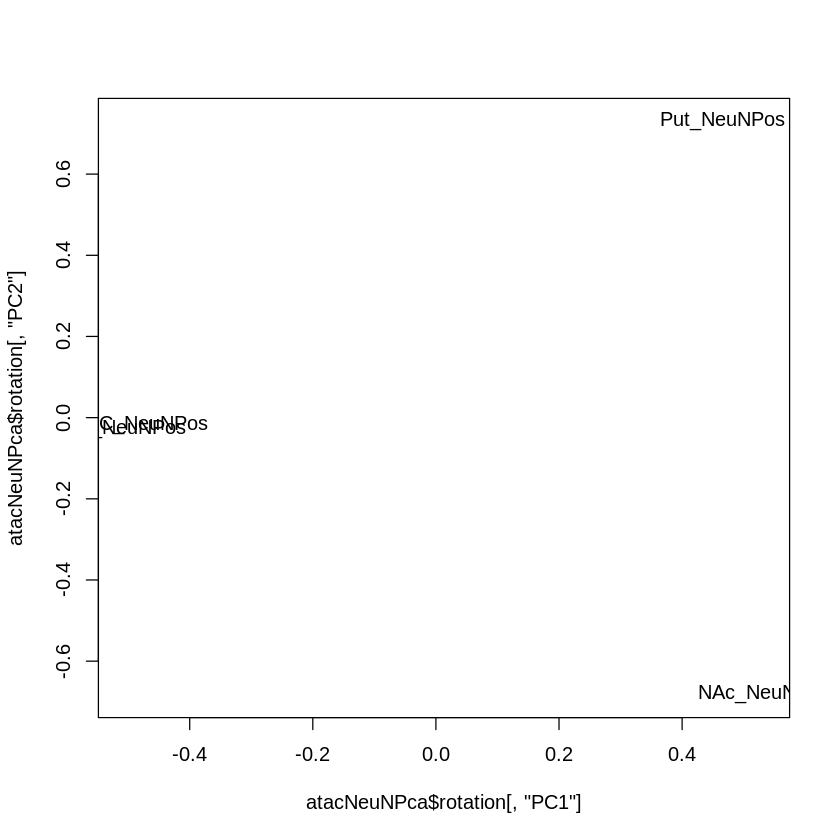

In [19]:
########## Plot the PCs ############

names(atacNeuNPca)

plot(x=atacNeuNPca$rotation[,"PC1"],y=atacNeuNPca$rotation[,"PC2"],type="n");
text(x=atacNeuNPca$rotation[,"PC1"],y=atacNeuNPca$rotation[,"PC2"],labels=rownames(atacNeuNPca$rotation));

#First PC separates cortex from striatum
#Second PC separates nucleus accumbens from putamen

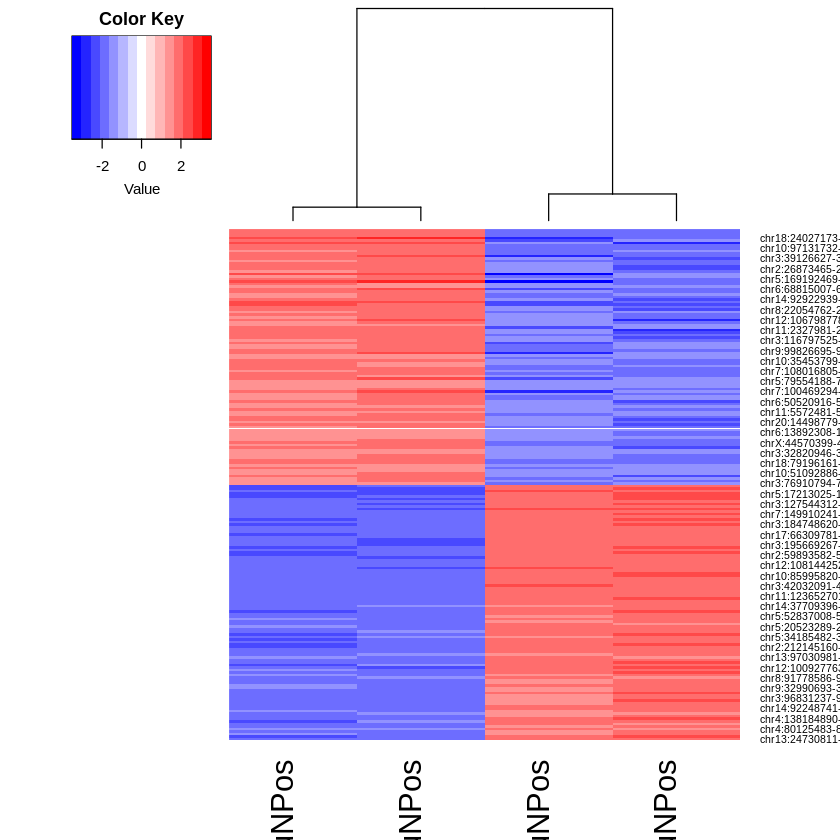

In [20]:
##########################################
##### Visualize differential open chromatin ######
##########################################

######## Print out heatmap of neuron only data #########
atacCpmNeuNHm1M <- atacCpmNeuNFilt3M[c(cortexUpV[1:100],striatumUpV[1:100]),];

#png(file="heatmapHw5Epi.1.png",width=1000,height=1000)
heatmap.2(atacCpmNeuNHm1M,trace="none",Colv=TRUE, Rowv=FALSE, dendrogram="column", density.info="none", col="bluered");
#dev.off()



In [21]:
######## Print out a barplot of the top candidates #########
curSigRegionName <- "chr2:3451259-3451551";
ggplot1F <- atacNeuNSampInfoF;
ggplot1F$curGene <- atacCpmNeuNFilt2M[curSigRegionName,]




In [22]:
ggplot1F


,id,BrainRegion,RegionAbv,CellType,brainStructureT,CellTypeT,curGene
,<chr>,<chr>,<chr>,<chr>,<fct>,<fct>,<dbl>
M1_NeuNPos,M1_NeuNPos,Primary motor cortex,M1,NeuNPos,cortex,NeuNPos,3.118462
dlPFC_NeuNPos,dlPFC_NeuNPos,Dorsolateral prefrontal cortex,dlPFC,NeuNPos,cortex,NeuNPos,2.941829
Put_NeuNPos,Put_NeuNPos,Putamen,Put,NeuNPos,striatum,NeuNPos,7.093566
NAc_NeuNPos,NAc_NeuNPos,Nucleus accumbens,NAc,NeuNPos,striatum,NeuNPos,7.140380


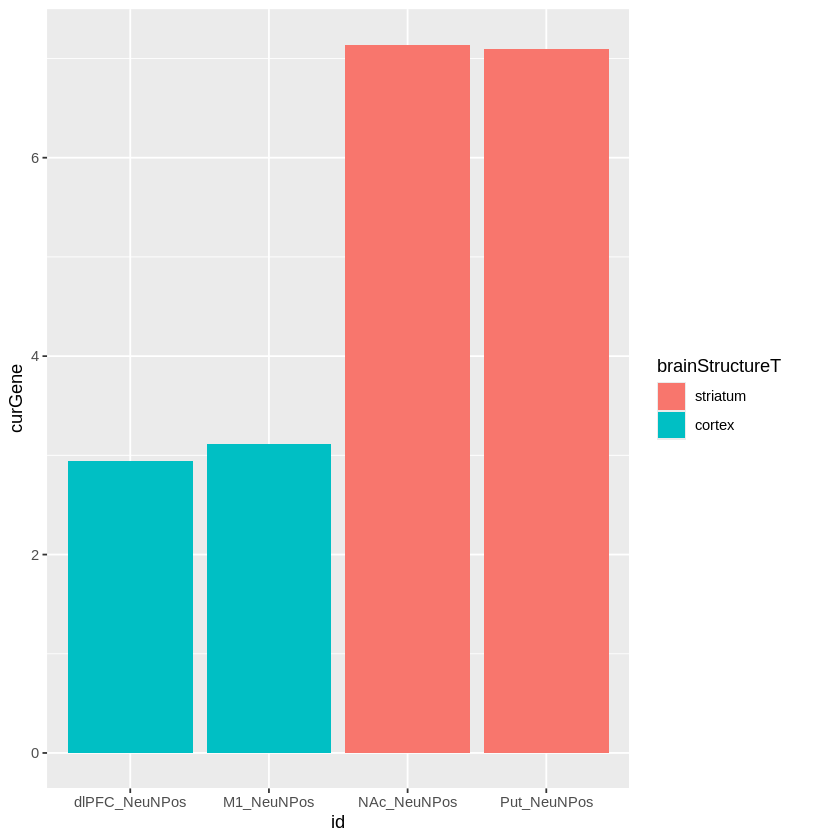

In [23]:
curPlot <- ggplot(data=ggplot1F, aes(x=id, y=curGene, fill=brainStructureT)) +
  geom_bar(stat="identity")

curPlot